In [ ]:
# Source: 

In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# ----------------------------
# 1. Load dataset
# ----------------------------
# (Download from Kaggle: https://www.kaggle.com/mlg-ulb/creditcardfraud)
df = pd.read_parquet("creditcard.parquet")

print("Dataset shape:", df.shape)
print("Fraud cases:", df['Class'].sum())

# Features = transaction details, Target = fraud (1) or not (0)
X = df.drop("Class", axis=1)
y = df["Class"]

# ----------------------------
# 2. Train-test split
# ----------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.3, 
                                                    random_state=42, 
                                                    stratify=y)

# ----------------------------
# 3. Unsupervised anomaly detection (Isolation Forest)
# ----------------------------
iso = IsolationForest(contamination=0.0017, random_state=42)  # fraud ratio ~0.17%
y_pred_iso = iso.fit_predict(X_test)

# IsolationForest outputs: -1 = anomaly, 1 = normal
y_pred_iso = np.where(y_pred_iso == -1, 1, 0)

print("\nIsolation Forest Performance:")
print(confusion_matrix(y_test, y_pred_iso))
print(classification_report(y_test, y_pred_iso, digits=4))

# ----------------------------
# 4. Supervised classification (Random Forest)
# ----------------------------
rf = RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("\nRandom Forest Performance:")
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf, digits=4))

# ----------------------------
# 5. Hybrid approach (Optional idea)
# ----------------------------
# You could combine both:
# - Use IsolationForest to flag suspicious transactions
# - Then pass them to RandomForest for classification


Dataset shape: (284807, 31)
Fraud cases: 492

Isolation Forest Performance:
[[85182   113]
 [  115    33]]
              precision    recall  f1-score   support

           0     0.9987    0.9987    0.9987     85295
           1     0.2260    0.2230    0.2245       148

    accuracy                         0.9973     85443
   macro avg     0.6123    0.6108    0.6116     85443
weighted avg     0.9973    0.9973    0.9973     85443


Random Forest Performance:
[[85292     3]
 [   44   104]]
              precision    recall  f1-score   support

           0     0.9995    1.0000    0.9997     85295
           1     0.9720    0.7027    0.8157       148

    accuracy                         0.9994     85443
   macro avg     0.9857    0.8513    0.9077     85443
weighted avg     0.9994    0.9994    0.9994     85443



In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Load dataset
df = pd.read_parquet("creditcard.parquet")
X = df.drop("Class", axis=1)
y = df["Class"]

# Train-test split (stratified to keep fraud ratio same)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# ----------------------------
# 1. Random Forest WITHOUT balancing
# ----------------------------
rf_plain = RandomForestClassifier(n_estimators=100, random_state=42)
rf_plain.fit(X_train, y_train)
y_pred_plain = rf_plain.predict(X_test)

print("\n--- Random Forest (No Balancing) ---")
print(confusion_matrix(y_test, y_pred_plain))
print(classification_report(y_test, y_pred_plain, digits=4))

# ----------------------------
# 2. Random Forest WITH balancing
# ----------------------------
rf_balanced = RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42)
rf_balanced.fit(X_train, y_train)
y_pred_balanced = rf_balanced.predict(X_test)

print("\n--- Random Forest (With Balancing) ---")
print(confusion_matrix(y_test, y_pred_balanced))
print(classification_report(y_test, y_pred_balanced, digits=4))



--- Random Forest (No Balancing) ---
[[85290     5]
 [   36   112]]
              precision    recall  f1-score   support

           0     0.9996    0.9999    0.9998     85295
           1     0.9573    0.7568    0.8453       148

    accuracy                         0.9995     85443
   macro avg     0.9784    0.8783    0.9225     85443
weighted avg     0.9995    0.9995    0.9995     85443


--- Random Forest (With Balancing) ---
[[85292     3]
 [   44   104]]
              precision    recall  f1-score   support

           0     0.9995    1.0000    0.9997     85295
           1     0.9720    0.7027    0.8157       148

    accuracy                         0.9994     85443
   macro avg     0.9857    0.8513    0.9077     85443
weighted avg     0.9994    0.9994    0.9994     85443



                     value
timestamp                 
2015-02-26 21:42:53    104
2015-02-26 21:47:53    100
2015-02-26 21:52:53     99
2015-02-26 21:57:53    154
2015-02-26 22:02:53    120


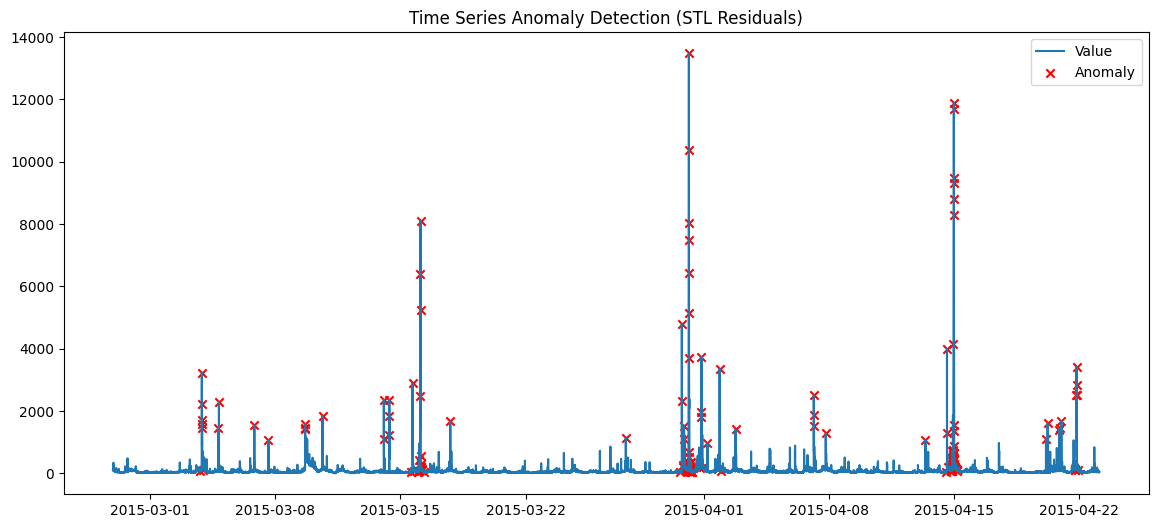

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL
import numpy as np

# ----------------------------
# 1. Load dataset (replace with Kaggle path)
# Example: "realTweets/Twitter_volume_AAPL.csv" from NAB dataset
# ----------------------------
df = pd.read_csv(r"C:\Users\ekadw\Documents\DATA\Anomalies\realTweets\realTweets\Twitter_volume_AAPL.csv")
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.set_index("timestamp")

print(df.head())

# ----------------------------
# 2. Decompose the time series
# ----------------------------
stl = STL(df["value"], period=24)  # period=24 for daily cycle (adjust as needed)
res = stl.fit()

# ----------------------------
# 3. Detect anomalies based on residuals
# ----------------------------
residual = res.resid
threshold = 3 * residual.std()   # simple z-score threshold

df["anomaly"] = (abs(residual) > threshold).astype(int)

# ----------------------------
# 4. Visualization
# ----------------------------
plt.figure(figsize=(14,6))
plt.plot(df.index, df["value"], label="Value")
plt.scatter(df.index[df["anomaly"]==1], df["value"][df["anomaly"]==1],
            color="red", label="Anomaly", marker="x")
plt.title("Time Series Anomaly Detection (STL Residuals)")
plt.legend()
plt.show()


                     value
timestamp                 
2015-02-26 21:42:53    104
2015-02-26 21:47:53    100
2015-02-26 21:52:53     99
2015-02-26 21:57:53    154
2015-02-26 22:02:53    120


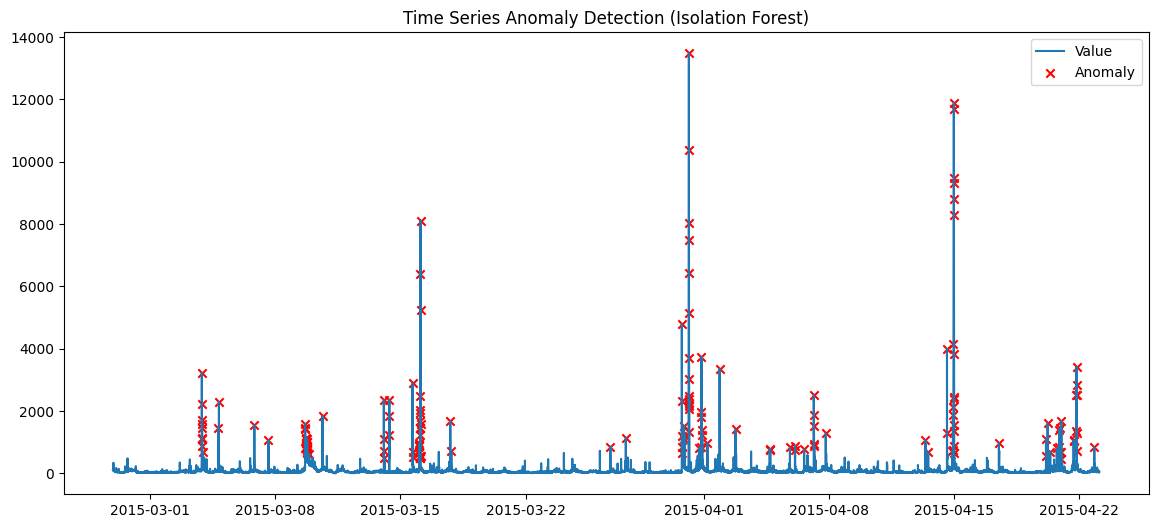

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

# ----------------------------
# 1. Load dataset (example from NAB: Twitter stock volume)
# ----------------------------
df = pd.read_csv(r"C:\Users\ekadw\Documents\DATA\Anomalies\realTweets\realTweets\Twitter_volume_AAPL.csv")
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.set_index("timestamp")

print(df.head())

# ----------------------------
# 2. Feature engineering
# Isolation Forest needs numeric features
# ----------------------------
df["hour"] = df.index.hour
df["dayofweek"] = df.index.dayofweek

features = df[["value", "hour", "dayofweek"]]

# ----------------------------
# 3. Fit Isolation Forest
# ----------------------------
iso = IsolationForest(
    contamination=0.01,  # expected anomaly proportion
    random_state=42
)

df["anomaly"] = iso.fit_predict(features)

# Convert labels: -1 = anomaly, 1 = normal
df["anomaly"] = df["anomaly"].map({1: 0, -1: 1})

# ----------------------------
# 4. Visualization
# ----------------------------
plt.figure(figsize=(14,6))
plt.plot(df.index, df["value"], label="Value")
plt.scatter(df.index[df["anomaly"]==1], 
            df["value"][df["anomaly"]==1],
            color="red", label="Anomaly", marker="x")
plt.title("Time Series Anomaly Detection (Isolation Forest)")
plt.legend()
plt.show()


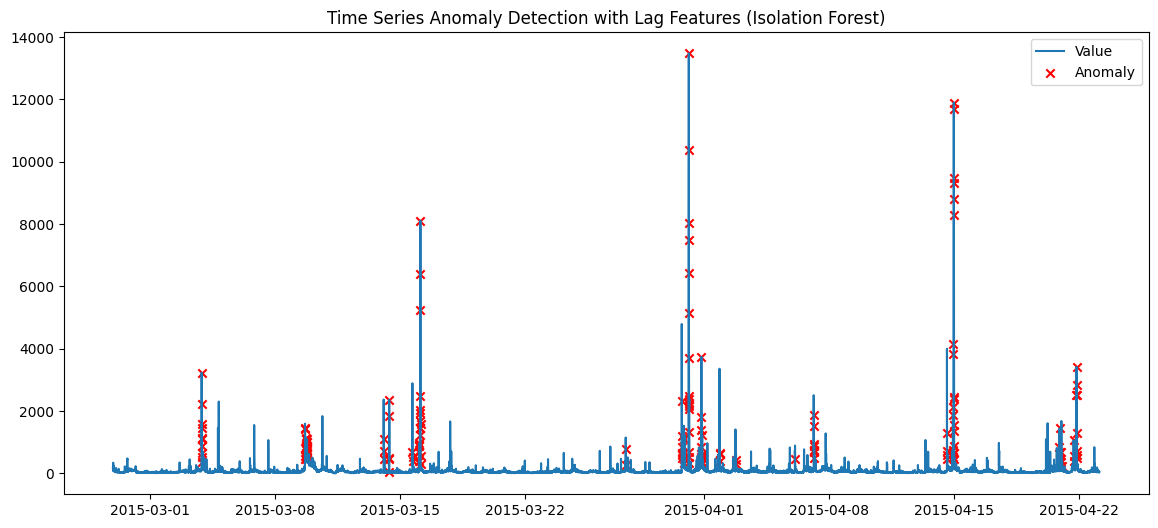

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

# ----------------------------
# 1. Load dataset (example NAB: Twitter stock volume)
# ----------------------------
df = pd.read_csv(r"C:\Users\ekadw\Documents\DATA\Anomalies\realTweets\realTweets\Twitter_volume_AAPL.csv")
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.set_index("timestamp")

# ----------------------------
# 2. Create lag features
# ----------------------------
df["lag1"] = df["value"].shift(1)
df["lag2"] = df["value"].shift(2)
df["lag3"] = df["value"].shift(3)

# Drop first few NaNs caused by shift
df = df.dropna()

# ----------------------------
# 3. Feature set
# ----------------------------
features = df[["value", "lag1", "lag2", "lag3"]]

# ----------------------------
# 4. Fit Isolation Forest
# ----------------------------
iso = IsolationForest(
    contamination=0.01,  # assume 1% anomalies
    random_state=42
)
df["anomaly"] = iso.fit_predict(features)

# Convert labels: -1 = anomaly, 1 = normal
df["anomaly"] = df["anomaly"].map({1: 0, -1: 1})

# ----------------------------
# 5. Visualization
# ----------------------------
plt.figure(figsize=(14,6))
plt.plot(df.index, df["value"], label="Value")
plt.scatter(df.index[df["anomaly"]==1],
            df["value"][df["anomaly"]==1],
            color="red", label="Anomaly", marker="x")
plt.title("Time Series Anomaly Detection with Lag Features (Isolation Forest)")
plt.legend()
plt.show()


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, RepeatVector, TimeDistributed

# ----------------------------
# 1. Load dataset
# ----------------------------
df = pd.read_csv(r"C:\Users\ekadw\Documents\DATA\Anomalies\realTweets\realTweets\Twitter_volume_AAPL.csv")
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.set_index("timestamp")

values = df["value"].values.reshape(-1, 1)

# ----------------------------
# 2. Normalize data
# ----------------------------
scaler = MinMaxScaler()
values_scaled = scaler.fit_transform(values)

# ----------------------------
# 3. Create sequences
# ----------------------------
def create_sequences(data, seq_len=30):
    X = []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
    return np.array(X)

SEQ_LEN = 30
X = create_sequences(values_scaled, SEQ_LEN)

print("Shape of input sequences:", X.shape)  # (samples, timesteps, features)

# ----------------------------
# 4. Build LSTM Autoencoder
# ----------------------------
model = Sequential([
    LSTM(64, activation="relu", input_shape=(SEQ_LEN, 1), return_sequences=True),
    LSTM(32, activation="relu", return_sequences=False),
    RepeatVector(SEQ_LEN),
    LSTM(32, activation="relu", return_sequences=True),
    LSTM(64, activation="relu", return_sequences=True),
    TimeDistributed(Dense(1))
])

model.compile(optimizer="adam", loss="mse")
model.summary()

# ----------------------------
# 5. Train model
# ----------------------------
history = model.fit(
    X, X,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    shuffle=False
)

# ----------------------------
# 6. Reconstruction errors
# ----------------------------
X_pred = model.predict(X)
mse = np.mean(np.power(X - X_pred, 2), axis=(1,2))

# Threshold = mean + 3*std (or tune using validation set)
threshold = np.mean(mse) + 3*np.std(mse)
print("Threshold:", threshold)

# ----------------------------
# 7. Mark anomalies
# ----------------------------
anomalies = mse > threshold

# Align anomalies with original data index
anomaly_index = df.index[SEQ_LEN:]
df_anomaly = df.iloc[SEQ_LEN:].copy()
df_anomaly["reconstruction_error"] = mse
df_anomaly["anomaly"] = anomalies.astype(int)

# ----------------------------
# 8. Visualization
# ----------------------------
plt.figure(figsize=(14,6))
plt.plot(df.index, df["value"], label="Value")
plt.scatter(df_anomaly.index[df_anomaly["anomaly"]==1],
            df_anomaly["value"][df_anomaly["anomaly"]==1],
            color="red", label="Anomaly", marker="x")
plt.title("Time Series Anomaly Detection (LSTM Autoencoder)")
plt.legend()
plt.show()


Shape of input sequences: (15872, 30, 1)


C:\Users\ekadw\anaconda3\envs\SQLite\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 30, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 30, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 30, 64)         │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 30, 1)          │            65 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 62,529 (244.25 KB)

 Trainable params: 62,529 (244.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
447/447 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - loss: 6.2837e-04 - val_loss: 1.9944e-04
Epoch 2/20
447/447 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - loss: 6.2669e-04 - val_loss: 2.3008e-04
Epoch 3/20
447/447 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - loss: 6.2838e-04 - val_loss: 2.3208e-04
Epoch 4/20
447/447 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - loss: 6.2692e-04 - val_loss: 2.1158e-04
Epoch 5/20
447/447 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - loss: 1385520256.0000 - val_loss: 3.1993e-04
Epoch 6/20
447/447 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - loss: 6.9674e-04 - val_loss: 2.4817e-04
Epoch 7/20
447/447 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - loss: 6.6709e-04 - val_loss: 2.5023e-04
Epoch 8/20
  4/447 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - loss: 7.4187e-05 